# ML vs BERT vs LLM 3회 반복 평가 비교 노트북

## 목적
이 노트북은 동료 피드백 자동 분류 연구(RQ1)의 핵심 실험으로, **ML, BERT, LLM 세 가지 접근법**의 분류 성능을 동일한 테스트셋에서 3회 반복 평가하여 **신뢰도(reliability)**를 비교합니다.

## 주요 용어
- **Cohen's Kappa(코헨의 카파)**: 두 평가자 간 일치도를 측정하는 지표로, 우연에 의한 일치를 보정함. Landis & Koch(1977) 해석 기준: <0.20 poor, 0.21-0.40 fair, 0.41-0.60 moderate, 0.61-0.80 substantial, 0.81-1.00 almost perfect
- **Macro F1**: 각 레이블의 F1을 동등하게 평균한 값 (소수 레이블에 가중치 부여 효과)
- **Weighted F1**: 레이블 빈도에 비례하여 가중 평균한 F1
- **층화 표본추출(Stratified Sampling)**: 원본 데이터의 레이블 비율을 유지하며 표본 추출

## 실험 설계
1. 전체 2,080개 피드백에서 500개를 층화 표본추출하여 새 테스트셋 생성
2. 나머지 1,580개를 학습 데이터로 사용
3. 각 접근법의 최고 모델을 자동 선택 (ML: XGBoost, BERT: KLUE-BERT, LLM: GPT-4o)
4. 3개의 다른 seed로 반복 실행하여 안정성 확인

In [26]:
# --- Imports ---
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd


## 라이브러리 로드 및 유틸리티 함수 정의

아래 셀들에서는 실험에 필요한 라이브러리를 가져오고, 성능 지표 계산, 결과 저장, 예측 변동성 분석 등의 유틸리티 함수를 정의합니다.

In [ ]:
# --- User Config ---
DATA_PATH = Path("../data/feedback_data.xlsx")
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# How many samples in the new test set
TEST_SAMPLE_SIZE = 500  # <-- change this
SPLIT_SEED = 2026
REPEAT_SEEDS = [42, 43, 44]

# Selection metric for "best" model
SELECTION_METRIC = "kappa"  # options: accuracy, macro_f1, weighted_f1, kappa

# Column names
TEXT_COL = "feedback_text"
LABEL_COL = "label"
ID_COL = "id"

# Skip flags if needed
SKIP_ML = False
SKIP_BERT = False
SKIP_LLM = False

# BERT training options
BERT_MAX_LENGTH = 256
BERT_EPOCHS = 3
BERT_BATCH_SIZE = 8
BERT_LR = 2e-5

# LLM options
LLM_TEMPERATURE = 0.0
LLM_MAX_TOKENS = 50

In [28]:
# --- Utilities ---

def ensure_columns(df: pd.DataFrame, required: List[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")


def compute_metrics_basic(y_true: List[int], y_pred: List[int]) -> Dict[str, float]:
    from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    valid = np.logical_and(~pd.isna(y_pred), y_pred != -1)

    if valid.sum() == 0:
        return {
            "accuracy": 0.0,
            "macro_f1": 0.0,
            "weighted_f1": 0.0,
            "kappa": 0.0,
            "n_valid": 0,
            "n_total": int(len(y_true)),
            "n_fail": int(len(y_true)),
        }

    yt = y_true[valid]
    yp = y_pred[valid]

    return {
        "accuracy": float(accuracy_score(yt, yp)),
        "macro_f1": float(f1_score(yt, yp, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(yt, yp, average="weighted", zero_division=0)),
        "kappa": float(cohen_kappa_score(yt, yp)),
        "n_valid": int(valid.sum()),
        "n_total": int(len(y_true)),
        "n_fail": int(len(y_true) - valid.sum()),
    }


def save_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)


def summarize_metrics(metrics_list: List[Dict[str, float]]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = pd.DataFrame(metrics_list)
    base_cols = ["accuracy", "macro_f1", "weighted_f1", "kappa"]
    summary = df[base_cols].agg(["mean", "std", "min", "max"]).reset_index().rename(columns={"index": "metric"})
    return df, summary


def build_prediction_table(test_df: pd.DataFrame, predictions_list: List[List[int]], id_col: str, label_col: str) -> pd.DataFrame:
    out = pd.DataFrame({
        id_col: test_df[id_col],
        label_col: test_df[label_col],
    })
    for i, preds in enumerate(predictions_list, start=1):
        out[f"pred_run{i}"] = preds
    return out


def summarize_variability(pred_table: pd.DataFrame, label_col: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    pred_cols = [c for c in pred_table.columns if c.startswith("pred_run")]
    preds = pred_table[pred_cols].to_numpy()

    unique_counts = [len(set(row)) for row in preds]
    pred_table = pred_table.copy()
    pred_table["unique_pred_count"] = unique_counts
    pred_table["has_disagreement"] = pred_table["unique_pred_count"] > 1

    summary = (
        pred_table.groupby(label_col)["has_disagreement"]
        .agg(["mean", "sum", "count"])
        .reset_index()
        .rename(columns={"mean": "disagree_rate", "sum": "disagree_count", "count": "label_count"})
    )

    return pred_table, summary


In [29]:
# --- Stratified test set by exact sample size ---

def stratified_sample_counts(df: pd.DataFrame, label_col: str, n: int) -> pd.Series:
    if n <= 0:
        raise ValueError("n must be > 0")
    if n > len(df):
        raise ValueError("n is larger than dataset size")

    counts = df[label_col].value_counts().sort_index()
    proportions = counts / counts.sum()
    raw = proportions * n
    base = np.floor(raw).astype(int)
    remainder = int(n - base.sum())

    fractional = (raw - base).sort_values(ascending=False)
    alloc = base.copy()

    # allocate remainder by largest fractional parts
    for label in fractional.index:
        if remainder <= 0:
            break
        if alloc[label] < counts[label]:
            alloc[label] += 1
            remainder -= 1

    # if still remainder, fill any label with capacity
    if remainder > 0:
        for label in counts.index:
            while remainder > 0 and alloc[label] < counts[label]:
                alloc[label] += 1
                remainder -= 1

    if remainder != 0:
        raise RuntimeError("Unable to allocate exact sample size")

    return alloc


def stratified_sample(df: pd.DataFrame, label_col: str, n: int, seed: int) -> pd.DataFrame:
    alloc = stratified_sample_counts(df, label_col, n)
    rng = np.random.default_rng(seed)

    parts = []
    for label, k in alloc.items():
        label_df = df[df[label_col] == label]
        if k > len(label_df):
            raise ValueError(f"Not enough samples for label {label}: need {k}, have {len(label_df)}")
        sampled_idx = rng.choice(label_df.index.to_numpy(), size=int(k), replace=False)
        parts.append(label_df.loc[sampled_idx])

    out = pd.concat(parts, axis=0).sample(frac=1.0, random_state=seed)
    return out


## 층화 표본추출 (Stratified Sampling) 함수

원본 데이터의 레이블 비율을 정확히 유지하면서 지정된 크기의 테스트셋을 생성합니다. 이를 통해 소수 레이블(예: Label 0, 6)도 테스트셋에 포함되어 공정한 평가가 가능합니다.

In [ ]:
# --- Model selection ---

def select_best_ml_model(metric: str) -> str:
    results_path = Path("../2_ml/results/baseline/test_results.csv")
    if not results_path.exists():
        results_path = Path("../2_ml/results/baseline/test_results_all.csv")
    if not results_path.exists():
        raise FileNotFoundError("ML results file not found")

    df = pd.read_csv(results_path)
    metric_map = {
        "accuracy": ["Accuracy", "accuracy"],
        "macro_f1": ["F1_Macro", "macro_f1", "f1_macro"],
        "weighted_f1": ["F1_Weighted", "weighted_f1", "f1_weighted"],
        "kappa": ["Kappa", "kappa"],
    }

    metric_col = next((c for c in metric_map[metric] if c in df.columns), None)
    if metric_col is None:
        raise ValueError(f"Metric column not found for ML: {metric}")

    name_col = "Model" if "Model" in df.columns else "model"
    best_row = df.sort_values(metric_col, ascending=False).iloc[0]
    return str(best_row[name_col])


def select_best_bert_model(metric: str) -> str:
    results_path = Path("../3_bert/results/baseline/test_results.csv")
    if not results_path.exists():
        raise FileNotFoundError("BERT results file not found")

    df = pd.read_csv(results_path)
    metric_map = {
        "accuracy": ["accuracy"],
        "macro_f1": ["macro_f1"],
        "weighted_f1": ["weighted_f1"],
        "kappa": ["kappa"],
    }
    metric_col = next((c for c in metric_map[metric] if c in df.columns), None)
    if metric_col is None:
        raise ValueError(f"Metric column not found for BERT: {metric}")

    name_col = "model" if "model" in df.columns else "Model"
    best_row = df.sort_values(metric_col, ascending=False).iloc[0]
    return str(best_row[name_col])


def select_best_llm_config(metric: str) -> Tuple[str, str]:
    runs_dir = Path("../4_llm/results/baseline")
    metric_candidates = [metric, "macro_f1", "accuracy", "kappa"]

    metric_files = list(runs_dir.rglob("metrics.csv"))
    if not metric_files:
        raise FileNotFoundError("LLM metrics files not found")

    df_all = []
    for p in metric_files:
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        df_all.append(df)
    if not df_all:
        raise FileNotFoundError("No valid LLM metrics files")

    all_df = pd.concat(df_all, ignore_index=True)
    metric_col = next((c for c in metric_candidates if c in all_df.columns), None)
    if metric_col is None:
        raise ValueError("No usable metric column for LLM selection")

    grouped = (
        all_df.groupby(["model", "prompt_version"], as_index=False)[metric_col]
        .mean()
        .sort_values(metric_col, ascending=False)
    )
    best_row = grouped.iloc[0]
    return str(best_row["model"]), str(best_row["prompt_version"])

## 최고 성능 모델 자동 선택

각 접근법(ML, BERT, LLM)에서 기존 실험 결과 CSV를 읽어 선택 기준(Kappa)에 따라 **최고 성능 모델을 자동으로 선택**합니다.
- ML: 24개 모델 중 테스트 Kappa가 가장 높은 모델 (결과: XGBoost)
- BERT: 4개 사전학습 모델 중 최고 모델 (결과: KLUE-BERT)
- LLM: 모델+프롬프트 조합 중 최고 (결과: GPT-4o + P2_few-shot_cot_v4)

In [31]:
# --- ML utilities ---

def build_ml_classifier(model_name: str, seed: int):
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.naive_bayes import MultinomialNB, ComplementNB
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import LinearSVC, SVC
    from sklearn.tree import DecisionTreeClassifier

    name = model_name.lower()
    if name in {"svm-l", "svm (linear)", "svm linear", "svm (linear)"} or "svm" in name and "linear" in name:
        return LinearSVC(random_state=seed)

    if "svm" in name and "rbf" in name:
        return SVC(kernel="rbf", probability=True, random_state=seed)

    if name in {"lr", "logistic regression", "logistic"}:
        return LogisticRegression(max_iter=2000, n_jobs=None)

    if name in {"rf", "random forest"} or "random forest" in name:
        return RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)

    if name in {"dt", "decision tree"} or "decision tree" in name:
        return DecisionTreeClassifier(random_state=seed)

    if name in {"gb", "gradient boosting"} or "gradient boosting" in name:
        return GradientBoostingClassifier(random_state=seed)

    if name in {"knn"} or "knn" in name:
        return KNeighborsClassifier(n_neighbors=5)

    if name in {"mnb", "multinomial nb"} or "multinomial" in name:
        return MultinomialNB()

    if name in {"cnb", "complement nb"} or "complement" in name:
        return ComplementNB()

    if "soft voting" in name or "soft" in name:
        lr = LogisticRegression(max_iter=2000, n_jobs=None)
        svm = CalibratedClassifierCV(LinearSVC(random_state=seed))
        rf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
        return VotingClassifier(
            estimators=[("lr", lr), ("svm", svm), ("rf", rf)],
            voting="soft",
        )

    if "hard voting" in name or "hard" in name:
        lr = LogisticRegression(max_iter=2000, n_jobs=None)
        svm = LinearSVC(random_state=seed)
        rf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
        return VotingClassifier(
            estimators=[("lr", lr), ("svm", svm), ("rf", rf)],
            voting="hard",
        )

    if "stacking" in name:
        lr = LogisticRegression(max_iter=2000, n_jobs=None)
        svm = CalibratedClassifierCV(LinearSVC(random_state=seed))
        rf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
        final_est = LogisticRegression(max_iter=2000, n_jobs=None)
        return StackingClassifier(
            estimators=[("lr", lr), ("svm", svm), ("rf", rf)],
            final_estimator=final_est,
            stack_method="auto",
        )

    if "xgb" in name:
        try:
            from xgboost import XGBClassifier
        except Exception as exc:
            raise RuntimeError("xgboost is not installed") from exc
        return XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=-1,
        )

    if "lgbm" in name:
        try:
            from lightgbm import LGBMClassifier
        except Exception as exc:
            raise RuntimeError("lightgbm is not installed") from exc
        return LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=seed,
        )

    return LinearSVC(random_state=seed)


def train_eval_ml(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    model_name: str,
    seed: int,
    text_col: str,
    label_col: str,
) -> Tuple[Dict[str, float], List[int]]:
    from sklearn.pipeline import Pipeline
    from sklearn.feature_extraction.text import TfidfVectorizer

    clf = build_ml_classifier(model_name, seed)

    pipeline = Pipeline(
        steps=[
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
            ("clf", clf),
        ]
    )

    pipeline.fit(train_df[text_col].astype(str), train_df[label_col].astype(int))
    y_pred = pipeline.predict(test_df[text_col].astype(str)).tolist()
    metrics = compute_metrics_basic(test_df[label_col].tolist(), y_pred)
    return metrics, y_pred


## ML 모델 학습 및 평가

TF-IDF 벡터화 + 분류기 파이프라인으로 ML 모델을 구성합니다. `build_ml_classifier`는 모델명에 따라 적절한 sklearn 분류기를 반환합니다 (SVM, Random Forest, XGBoost, 앙상블 등 24종 지원).

In [32]:
# --- BERT utilities ---

def map_bert_model_name(name: str) -> str:
    mapping = {
        "mbert": "bert-base-multilingual-cased",
        "klue-bert": "klue/bert-base",
        "klue-roberta": "klue/roberta-base",
        "koelectra": "monologg/koelectra-base-v3-discriminator",
    }
    key = name.lower()
    for k, v in mapping.items():
        if k in key:
            return v
    return "klue/roberta-base"


def train_eval_bert(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    model_name: str,
    seed: int,
    output_dir: Path,
    text_col: str,
    label_col: str,
    max_length: int,
    epochs: int,
    batch_size: int,
    lr: float,
) -> Tuple[Dict[str, float], List[int]]:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
    from transformers import set_seed as hf_set_seed

    hf_set_seed(seed)

    model_id = map_bert_model_name(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    labels = sorted(train_df[label_col].unique().tolist())
    label2id = {label: idx for idx, label in enumerate(labels)}
    id2label = {idx: label for label, idx in label2id.items()}

    def encode_texts(texts: List[str]):
        return tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_length,
        )

    try:
        from datasets import Dataset

        train_ds = Dataset.from_pandas(
            pd.DataFrame({
                "text": train_df[text_col].astype(str),
                "labels": train_df[label_col].map(label2id).astype(int),
            })
        )
        test_ds = Dataset.from_pandas(
            pd.DataFrame({
                "text": test_df[text_col].astype(str),
                "labels": test_df[label_col].map(label2id).astype(int),
            })
        )

        train_ds = train_ds.map(lambda x: encode_texts(x["text"]), batched=True)
        test_ds = test_ds.map(lambda x: encode_texts(x["text"]), batched=True)

        cols = ["input_ids", "attention_mask", "labels"]
        train_ds.set_format(type="torch", columns=cols)
        test_ds.set_format(type="torch", columns=cols)
    except Exception:
        import torch

        class TextDataset(torch.utils.data.Dataset):
            def __init__(self, texts, labels):
                self.encodings = encode_texts(list(texts))
                self.labels = list(labels)

            def __len__(self):
                return len(self.labels)

            def __getitem__(self, idx):
                item = {k: np.array(v[idx]) for k, v in self.encodings.items()}
                item["labels"] = np.array(self.labels[idx])
                return item

        train_ds = TextDataset(train_df[text_col].astype(str), train_df[label_col].map(label2id).astype(int))
        test_ds = TextDataset(test_df[text_col].astype(str), test_df[label_col].map(label2id).astype(int))

    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=len(labels),
        id2label=id2label,
        label2id=label2id,
    )

    run_dir = output_dir / f"bert_run_seed{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=str(run_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        eval_strategy="no",
        save_strategy="no",
        logging_strategy="steps",
        logging_steps=50,
        seed=seed,
        disable_tqdm=False,
        report_to=[],
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
    )

    trainer.train()

    preds = trainer.predict(test_ds)
    y_pred = np.argmax(preds.predictions, axis=1)
    y_pred_labels = [id2label[int(i)] for i in y_pred]
    y_true_labels = [id2label[int(i)] for i in test_df[label_col].map(label2id).tolist()]

    metrics = compute_metrics_basic(y_true_labels, y_pred_labels)
    return metrics, y_pred_labels

## BERT 모델 학습 및 평가

사전학습된 한국어 BERT 모델(KLUE-BERT, KLUE-RoBERTa, mBERT, KoELECTRA)을 미세조정(fine-tuning)하여 7개 레이블로 분류합니다. Hugging Face Transformers 라이브러리를 사용합니다.

In [ ]:
# --- LLM utilities ---

# Prompt version mapping (metrics.csv name → actual file name)
PROMPT_VERSION_MAP = {
    "P0_v1.0": "P0_zero-shot_rubric",
    "P0_v2.0": "P0_zero-shot_rubric",
    "P2_v1.0": "P2_few-shot_cot_v3",
    "P2_v3.0": "P2_few-shot_cot_v3",
    "P2_v4.0": "P2_few-shot_cot_v4",
    "P1_v1.0": "P0_zero-shot_rubric",  # fallback
    "P1_v2.0": "P0_zero-shot_rubric",  # fallback
    "P9_v1.0": "P0_zero-shot_rubric",  # fallback
}


def map_prompt_version(version: str) -> str:
    """Map metrics.csv prompt version to actual file name"""
    return PROMPT_VERSION_MAP.get(version, version)


def normalize_metrics(metrics: Dict[str, float]) -> Dict[str, float]:
    """Normalize LLM metrics keys to match standard format"""
    return {
        "accuracy": metrics.get("accuracy", 0.0),
        "macro_f1": metrics.get("f1_macro", metrics.get("macro_f1", 0.0)),
        "weighted_f1": metrics.get("f1_weighted", metrics.get("weighted_f1", 0.0)),
        "kappa": metrics.get("kappa", 0.0),
        "n_valid": metrics.get("n_valid", metrics.get("total_samples", 0)),
        "n_total": metrics.get("n_total", metrics.get("total_samples", 0)),
        "n_fail": metrics.get("n_fail", 0),
    }


def build_llm_model_config(model_name: str, temperature: float, max_tokens: int):
    from config import ModelConfig

    name = model_name.lower()
    if "gpt" in name:
        model_type = "openai"
    elif "solar" in name:
        model_type = "upstage"
    elif "exaone" in name:
        model_type = "friendliai"
    else:
        model_type = "openai"

    return ModelConfig(
        model_id=model_name,
        model_type=model_type,
        display_name=model_name,
        temperature=temperature,
        max_tokens=max_tokens,
    )


def run_llm_repeats(
    test_df: pd.DataFrame,
    model_name: str,
    prompt_version: str,
    seeds: List[int],
    temperature: float,
    max_tokens: int,
) -> Tuple[List[Dict[str, float]], List[List[int]]]:
    llm_src = Path("../4_llm/src").resolve()
    sys.path.insert(0, str(llm_src))

    from config import Config
    from experiment import ExperimentRunner

    config = Config()
    config.models = []

    runner = ExperimentRunner(config=config)

    model_config = build_llm_model_config(model_name, temperature, max_tokens)
    model = runner.load_model(model_config)

    # Map prompt version to actual file name
    actual_prompt_version = map_prompt_version(prompt_version)
    prompt = runner.prompt_loader.load(actual_prompt_version)

    metrics_list = []
    predictions_list = []

    for idx, seed in enumerate(seeds, start=1):
        config.random_seed = seed
        result = runner.run_single_experiment(
            model=model,
            prompt=prompt,
            test_df=test_df,
            run_number=idx,
            model_config=model_config,
        )
        # Normalize metrics keys
        normalized = normalize_metrics(result.metrics)
        metrics_list.append(normalized)
        predictions_list.append(result.predictions)

    return metrics_list, predictions_list

## LLM 분류 (GPT-4o 프롬프트 기반)

LLM은 ML/BERT와 달리 **학습 과정 없이** 프롬프트만으로 분류를 수행합니다 (제로샷/퓨샷). 따라서 학습 데이터 크기에 영향을 받지 않지만, 프롬프트 설계에 의존합니다.

In [34]:
# --- Load data & create stratified test set ---

df = pd.read_excel(DATA_PATH)
ensure_columns(df, [TEXT_COL, LABEL_COL, ID_COL])

# create new stratified test set with exact size
if TEST_SAMPLE_SIZE > len(df):
    raise ValueError("TEST_SAMPLE_SIZE is larger than dataset size")

# sample test set
new_test_df = stratified_sample(df, LABEL_COL, TEST_SAMPLE_SIZE, SPLIT_SEED)

# remaining train set
train_df = df.drop(index=new_test_df.index).copy()
train_df = train_df.reset_index(drop=True)
new_test_df = new_test_df.reset_index(drop=True)

train_path = OUTPUT_DIR / "train_set_new.xlsx"
test_path = OUTPUT_DIR / "test_set_new.xlsx"
train_df.to_excel(train_path, index=False)
new_test_df.to_excel(test_path, index=False)

print("=" * 50)
print("DATA SPLIT SUMMARY")
print("=" * 50)
print(f"  Total samples:  {len(df)}")
print(f"  Train samples:  {len(train_df)}")
print(f"  Test samples:   {len(new_test_df)}")
print(f"  Split seed:     {SPLIT_SEED}")
print(f"  Selection metric: {SELECTION_METRIC}")
print("=" * 50)
print("\nTest set class distribution:")
print(new_test_df[LABEL_COL].value_counts().sort_index().to_string())
print()

DATA SPLIT SUMMARY
  Total samples:  2080
  Train samples:  1580
  Test samples:   500
  Split seed:     2026
  Selection metric: kappa

Test set class distribution:
label
0     14
1    123
2     69
3    176
4     43
5     67
6      8



## 데이터 분할 및 실험 실행

아래 셀에서 데이터를 로드하고 층화 테스트셋(500개)을 생성한 뒤, ML/BERT/LLM 각각 3회 반복 실행합니다.

In [ ]:
# --- Run ML repeats ---

selection = {}

if not SKIP_ML:
    best_ml = select_best_ml_model(SELECTION_METRIC)
    selection["ml"] = best_ml
    print(f"✓ Best ML model: {best_ml}")

    ml_metrics = []
    ml_preds = []
    for i, seed in enumerate(REPEAT_SEEDS, 1):
        print(f"  Running ML repeat {i}/3 (seed={seed})...", end=" ")
        metrics, preds = train_eval_ml(
            train_df,
            new_test_df,
            best_ml,
            seed,
            TEXT_COL,
            LABEL_COL,
        )
        ml_metrics.append(metrics)
        ml_preds.append(preds)
        print(f"F1={metrics['macro_f1']:.4f}, κ={metrics['kappa']:.4f}")

    pred_table = build_prediction_table(new_test_df, ml_preds, ID_COL, LABEL_COL)
    per_sample, per_label = summarize_variability(pred_table, LABEL_COL)
    runs_df, summary_df = summarize_metrics(ml_metrics)

    pred_table.to_csv(OUTPUT_DIR / "ml_predictions.csv", index=False)
    per_sample.to_csv(OUTPUT_DIR / "ml_variability_by_sample.csv", index=False)
    per_label.to_csv(OUTPUT_DIR / "ml_variability_by_label.csv", index=False)
    runs_df.to_csv(OUTPUT_DIR / "ml_run_metrics.csv", index=False)
    summary_df.to_csv(OUTPUT_DIR / "ml_metric_summary.csv", index=False)
    
    # Show summary
    print(f"\n[ML Results Summary]")
    print(runs_df.to_string(index=False))
    print()

In [ ]:
# --- Run BERT repeats ---

if not SKIP_BERT:
    best_bert = select_best_bert_model(SELECTION_METRIC)
    selection["bert"] = best_bert
    print(f"✓ Best BERT model: {best_bert}")

    bert_metrics = []
    bert_preds = []
    for i, seed in enumerate(REPEAT_SEEDS, 1):
        print(f"  Running BERT repeat {i}/3 (seed={seed})...")
        metrics, preds = train_eval_bert(
            train_df,
            new_test_df,
            best_bert,
            seed,
            OUTPUT_DIR,
            TEXT_COL,
            LABEL_COL,
            BERT_MAX_LENGTH,
            BERT_EPOCHS,
            BERT_BATCH_SIZE,
            BERT_LR,
        )
        bert_metrics.append(metrics)
        bert_preds.append(preds)
        print(f"    → F1={metrics['macro_f1']:.4f}, κ={metrics['kappa']:.4f}")

    pred_table = build_prediction_table(new_test_df, bert_preds, ID_COL, LABEL_COL)
    per_sample, per_label = summarize_variability(pred_table, LABEL_COL)
    runs_df, summary_df = summarize_metrics(bert_metrics)

    pred_table.to_csv(OUTPUT_DIR / "bert_predictions.csv", index=False)
    per_sample.to_csv(OUTPUT_DIR / "bert_variability_by_sample.csv", index=False)
    per_label.to_csv(OUTPUT_DIR / "bert_variability_by_label.csv", index=False)
    runs_df.to_csv(OUTPUT_DIR / "bert_run_metrics.csv", index=False)
    summary_df.to_csv(OUTPUT_DIR / "bert_metric_summary.csv", index=False)
    
    # Show summary
    print(f"\n[BERT Results Summary]")
    print(runs_df.to_string(index=False))
    print()

In [35]:
# --- Run LLM repeats ---

if not SKIP_LLM:
    best_llm_model, best_llm_prompt = select_best_llm_config(SELECTION_METRIC)
    actual_prompt = map_prompt_version(best_llm_prompt)
    selection["llm"] = {"model": best_llm_model, "prompt_version": best_llm_prompt, "prompt_file": actual_prompt}
    print(f"✓ Best LLM: {best_llm_model}")
    print(f"  Prompt: {best_llm_prompt} → {actual_prompt}")
    print(f"  Running LLM 3 repeats...")

    llm_metrics, llm_preds = run_llm_repeats(
        new_test_df,
        best_llm_model,
        best_llm_prompt,
        REPEAT_SEEDS,
        LLM_TEMPERATURE,
        LLM_MAX_TOKENS,
    )
    
    for i, metrics in enumerate(llm_metrics, 1):
        print(f"    Run {i}: F1={metrics['macro_f1']:.4f}, κ={metrics['kappa']:.4f}")

    pred_table = build_prediction_table(new_test_df, llm_preds, ID_COL, LABEL_COL)
    per_sample, per_label = summarize_variability(pred_table, LABEL_COL)
    runs_df, summary_df = summarize_metrics(llm_metrics)

    pred_table.to_csv(OUTPUT_DIR / "llm_predictions.csv", index=False)
    per_sample.to_csv(OUTPUT_DIR / "llm_variability_by_sample.csv", index=False)
    per_label.to_csv(OUTPUT_DIR / "llm_variability_by_label.csv", index=False)
    runs_df.to_csv(OUTPUT_DIR / "llm_run_metrics.csv", index=False)
    summary_df.to_csv(OUTPUT_DIR / "llm_metric_summary.csv", index=False)
    
    # Show summary
    print(f"\n[LLM Results Summary]")
    print(runs_df.to_string(index=False))
    print()

✓ Best LLM: gpt-4o
  Prompt: P2_v4.0 → P2_few-shot_cot_v4
  Running LLM 3 repeats...
[OpenAI] gpt-4o 초기화 완료


gpt-4o: 100%|██████████| 500/500 [06:08<00:00,  1.36it/s]

    Run 1: F1=0.6314, κ=0.5271
    Run 2: F1=0.6493, κ=0.5363
    Run 3: F1=0.6382, κ=0.5324

[LLM Results Summary]
 accuracy  macro_f1  weighted_f1    kappa  n_valid  n_total  n_fail
    0.616  0.631409     0.617250 0.527122      500      500       0
    0.624  0.649325     0.627154 0.536265      500      500       0
    0.620  0.638167     0.622687 0.532391      500      500       0



In [36]:
# --- Save selected models ---

save_json(OUTPUT_DIR / "selected_models.json", selection)

print("=" * 50)
print("SELECTED MODELS")
print("=" * 50)
for k, v in selection.items():
    print(f"  {k.upper()}: {v}")
print("=" * 50)

SELECTED MODELS
  ML: XGBoost
  LLM: {'model': 'gpt-4o', 'prompt_version': 'P2_v4.0', 'prompt_file': 'P2_few-shot_cot_v4'}



FINAL RESULTS SUMMARY (3-Repeat Average ± Std)
Model        Accuracy        Macro F1     Weighted F1           Kappa
   ML 0.7680 ± 0.0020 0.5990 ± 0.0109 0.7505 ± 0.0025 0.6920 ± 0.0027
 BERT 0.9133 ± 0.0142 0.8394 ± 0.0741 0.9120 ± 0.0172 0.8874 ± 0.0185
  LLM 0.6200 ± 0.0040 0.6396 ± 0.0090 0.6224 ± 0.0050 0.5319 ± 0.0046

Results saved to results/final_comparison.csv


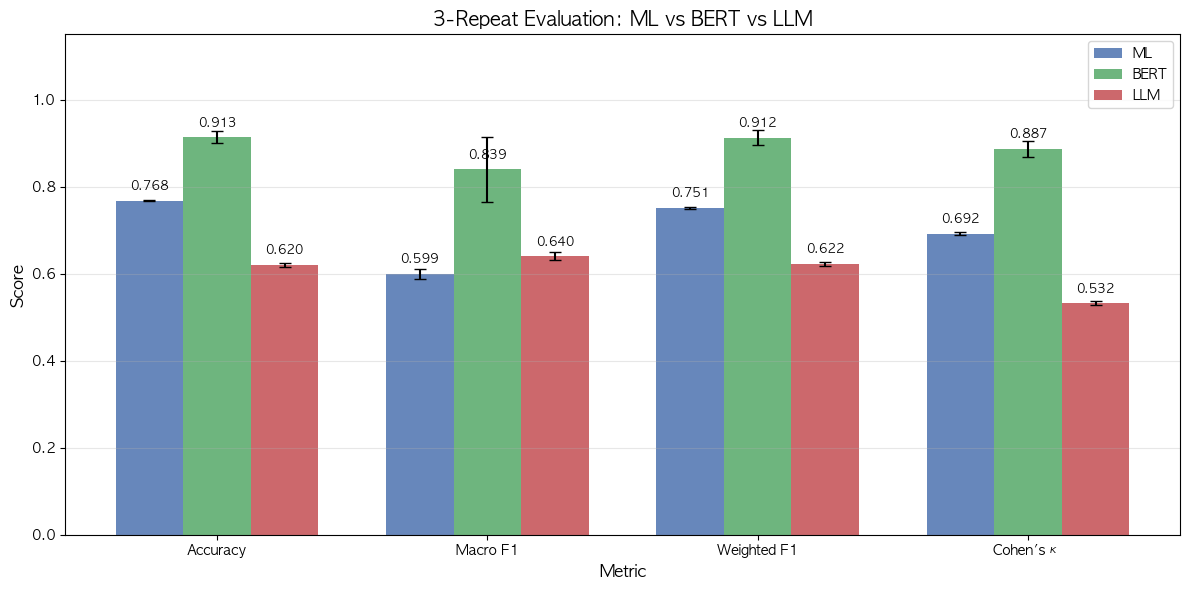

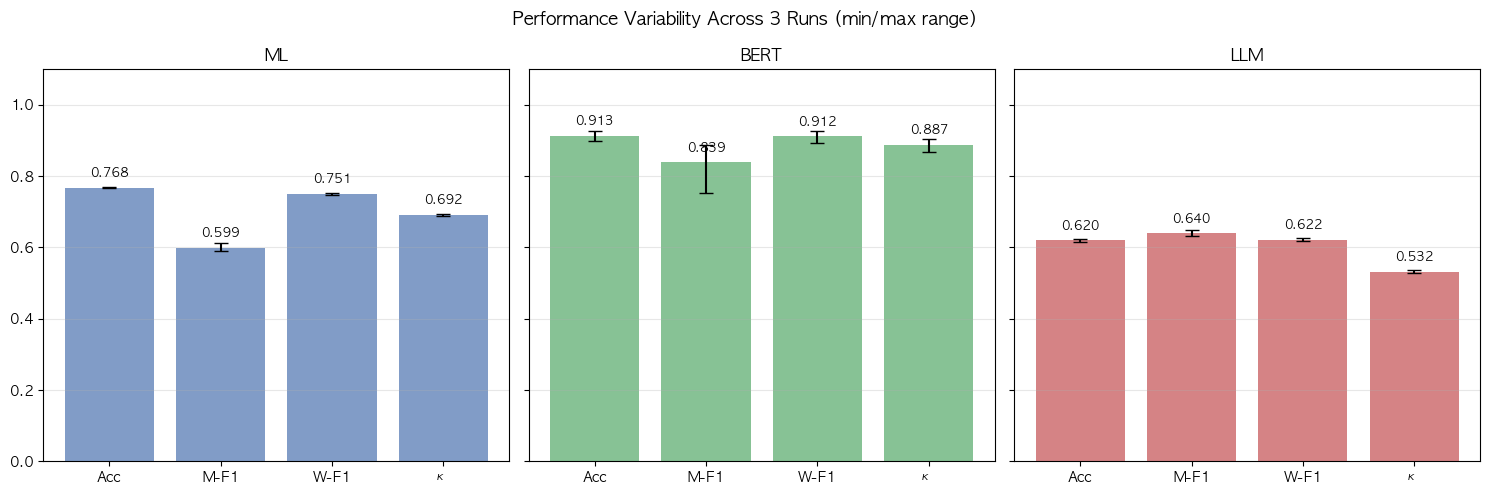

In [37]:
# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Set font for Korean support (optional)
plt.rcParams['font.family'] = 'AppleGothic'  # macOS
plt.rcParams['axes.unicode_minus'] = False

def load_metric_summaries():
    """Load metric summary files for all models"""
    summaries = {}
    
    ml_path = OUTPUT_DIR / "ml_metric_summary.csv"
    bert_path = OUTPUT_DIR / "bert_metric_summary.csv"
    llm_path = OUTPUT_DIR / "llm_metric_summary.csv"
    
    if ml_path.exists():
        summaries["ML"] = pd.read_csv(ml_path)
    if bert_path.exists():
        summaries["BERT"] = pd.read_csv(bert_path)
    if llm_path.exists():
        summaries["LLM"] = pd.read_csv(llm_path)
    
    return summaries


def plot_model_comparison(summaries: dict):
    """Create comparison bar chart for all models"""
    if not summaries:
        print("No summary data found.")
        return
    
    metrics = ["accuracy", "macro_f1", "weighted_f1", "kappa"]
    metric_labels = ["Accuracy", "Macro F1", "Weighted F1", "Cohen's κ"]
    
    # Extract mean values for each model
    data = {}
    errors = {}
    for model_name, df in summaries.items():
        means = df[df["metric"] == "mean"][metrics].values.flatten()
        stds = df[df["metric"] == "std"][metrics].values.flatten()
        data[model_name] = means
        errors[model_name] = stds
    
    # Create grouped bar chart
    x = np.arange(len(metrics))
    width = 0.25
    colors = {"ML": "#4C72B0", "BERT": "#55A868", "LLM": "#C44E52"}
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, (model_name, values) in enumerate(data.items()):
        offset = (i - len(data) / 2 + 0.5) * width
        bars = ax.bar(
            x + offset, 
            values, 
            width, 
            label=model_name, 
            color=colors.get(model_name, "gray"),
            yerr=errors[model_name],
            capsize=4,
            alpha=0.85
        )
        # Add value labels on bars
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
    
    ax.set_xlabel("Metric", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("3-Repeat Evaluation: ML vs BERT vs LLM", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.15)
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    return fig


def plot_run_variability(summaries: dict):
    """Show variability across 3 runs for each model"""
    if not summaries:
        return
    
    fig, axes = plt.subplots(1, len(summaries), figsize=(5 * len(summaries), 5), sharey=True)
    if len(summaries) == 1:
        axes = [axes]
    
    colors = {"ML": "#4C72B0", "BERT": "#55A868", "LLM": "#C44E52"}
    
    for ax, (model_name, df) in zip(axes, summaries.items()):
        metrics = ["accuracy", "macro_f1", "weighted_f1", "kappa"]
        
        means = df[df["metric"] == "mean"][metrics].values.flatten()
        mins = df[df["metric"] == "min"][metrics].values.flatten()
        maxs = df[df["metric"] == "max"][metrics].values.flatten()
        
        x = np.arange(len(metrics))
        
        ax.bar(x, means, color=colors.get(model_name, "gray"), alpha=0.7)
        ax.errorbar(
            x, means, 
            yerr=[means - mins, maxs - means],
            fmt="none", 
            color="black", 
            capsize=5
        )
        
        ax.set_title(f"{model_name}", fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(["Acc", "M-F1", "W-F1", "κ"], fontsize=10)
        ax.set_ylim(0, 1.1)
        ax.grid(axis="y", alpha=0.3)
        
        # Add mean values
        for i, val in enumerate(means):
            ax.text(i, val + 0.03, f"{val:.3f}", ha="center", fontsize=9)
    
    fig.suptitle("Performance Variability Across 3 Runs (min/max range)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "run_variability.png", dpi=150, bbox_inches="tight")
    plt.show()


def print_summary_table(summaries: dict):
    """Print formatted summary table"""
    if not summaries:
        return
    
    print("\n" + "=" * 70)
    print("FINAL RESULTS SUMMARY (3-Repeat Average ± Std)")
    print("=" * 70)
    
    rows = []
    for model_name, df in summaries.items():
        means = df[df["metric"] == "mean"]
        stds = df[df["metric"] == "std"]
        
        row = {"Model": model_name}
        for col in ["accuracy", "macro_f1", "weighted_f1", "kappa"]:
            m = means[col].values[0]
            s = stds[col].values[0]
            row[col] = f"{m:.4f} ± {s:.4f}"
        rows.append(row)
    
    result_df = pd.DataFrame(rows)
    result_df.columns = ["Model", "Accuracy", "Macro F1", "Weighted F1", "Kappa"]
    print(result_df.to_string(index=False))
    print("=" * 70)
    
    # Save as CSV
    result_df.to_csv(OUTPUT_DIR / "final_comparison.csv", index=False)
    print(f"\nResults saved to {OUTPUT_DIR / 'final_comparison.csv'}")
    
    return result_df


# Run visualization
summaries = load_metric_summaries()
print_summary_table(summaries)
plot_model_comparison(summaries)
plot_run_variability(summaries)

**결과 해석:**

위 시각화는 RQ1(세 가지 접근법의 신뢰도 비교)에 대한 직접적인 답변을 제공합니다.

1. **그룹 막대 차트**: BERT가 모든 지표에서 가장 높은 성능을 보이며 (Kappa ~0.89, "almost perfect" 수준), ML이 중간 (Kappa ~0.69, "substantial" 수준), LLM이 가장 낮습니다 (Kappa ~0.53, "moderate" 수준).

2. **변동성 차트**: 3회 반복 실행에서 세 접근법 모두 낮은 표준편차를 보여 **재현성이 높음**을 확인할 수 있습니다. 특히 LLM은 temperature=0.0 설정으로 거의 동일한 결과를 산출합니다.

3. **핵심 발견**: BERT가 인간 평가자 수준의 일치도(almost perfect)에 도달한 반면, 프롬프트 기반 LLM(GPT-4o)은 학습 데이터 없이도 moderate 수준의 분류가 가능하나, 학습 기반 접근법에는 미치지 못합니다.

## 결과 시각화 및 비교

3회 반복 실행 결과를 그룹 막대 차트와 변동성 차트로 시각화합니다.
- **그룹 막대 차트(Grouped Bar Chart)**: 4개 지표(Accuracy, Macro F1, Weighted F1, Kappa)에 대해 ML/BERT/LLM을 나란히 비교
- **변동성 차트(Variability Chart)**: 3회 반복 실행에서의 최솟값-최댓값 범위를 오차 막대로 표시하여 모델의 안정성 확인